# Minería de datos 2027-1
## Redes neuronales con PySpark y MLlib

**Curso:** Minería de datos  
**Profesor:** Dr. Ulises Olivares  

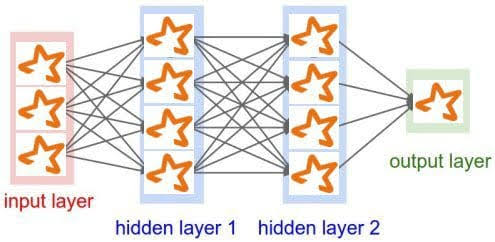


Este notebook presenta una red neuronal multicapa dentro de un flujo reproducible de PySpark.

El propósito no es sustituir TensorFlow o PyTorch, sino comprender qué puede aportar MLlib cuando los datos y la inferencia forman
parte de una canalización distribuida.




### Papel de cada componente

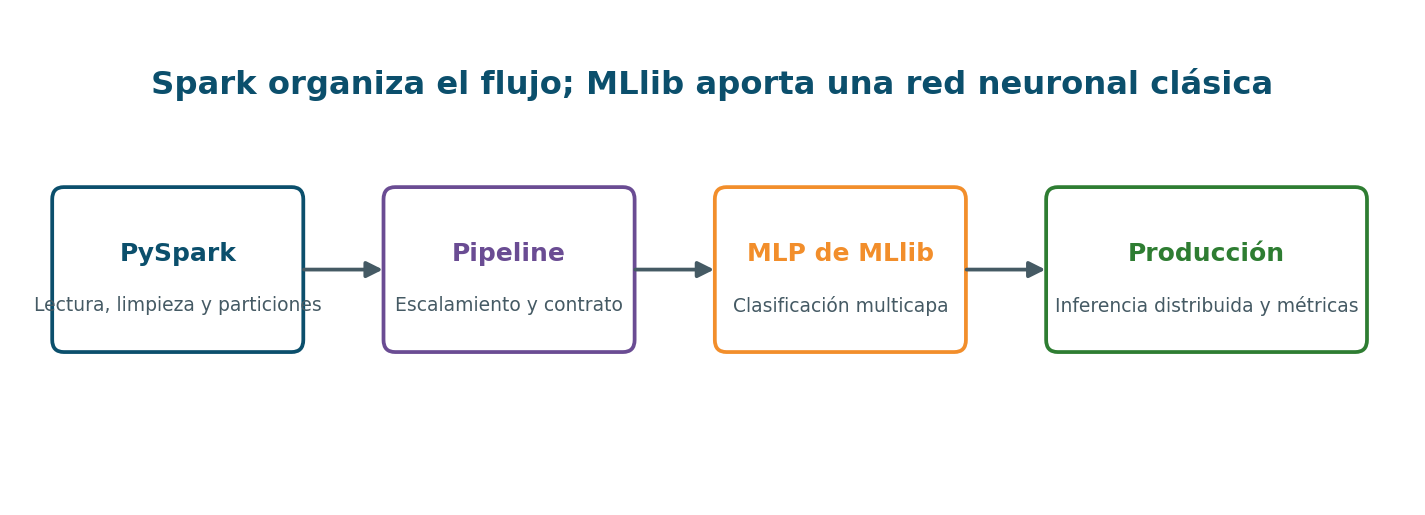

PySpark prepara y organiza los datos; el `Pipeline` conserva las transformaciones; MLlib ajusta un perceptrón multicapa; y `transform()` distribuye la inferencia. Esta separación permite razonar sobre el flujo completo, no solo sobre el modelo.

## 0. Alcance de las redes neuronales en PySpark

MLlib incluye `MultilayerPerceptronClassifier`, una red *feedforward* completamente conectada para clasificación.
Resulta útil para estudiar redes multicapa e integrarlas con DataFrames y pipelines, pero tiene límites importantes:

- no ofrece CNN, RNN, LSTM, GRU ni Transformer;
- no incluye *dropout*, normalización por lote o entrenamiento moderno con GPU;
- la arquitectura se especifica como tamaños de capas, con menos control que en bibliotecas profundas;
- para imágenes grandes o modelos profundos, Spark suele encargarse del ETL y TensorFlow/PyTorch del entrenamiento.

En este notebook se usa MLlib porque permite observar con claridad la integración entre datos distribuidos,
transformaciones, entrenamiento e inferencia.

### De entradas a una predicción

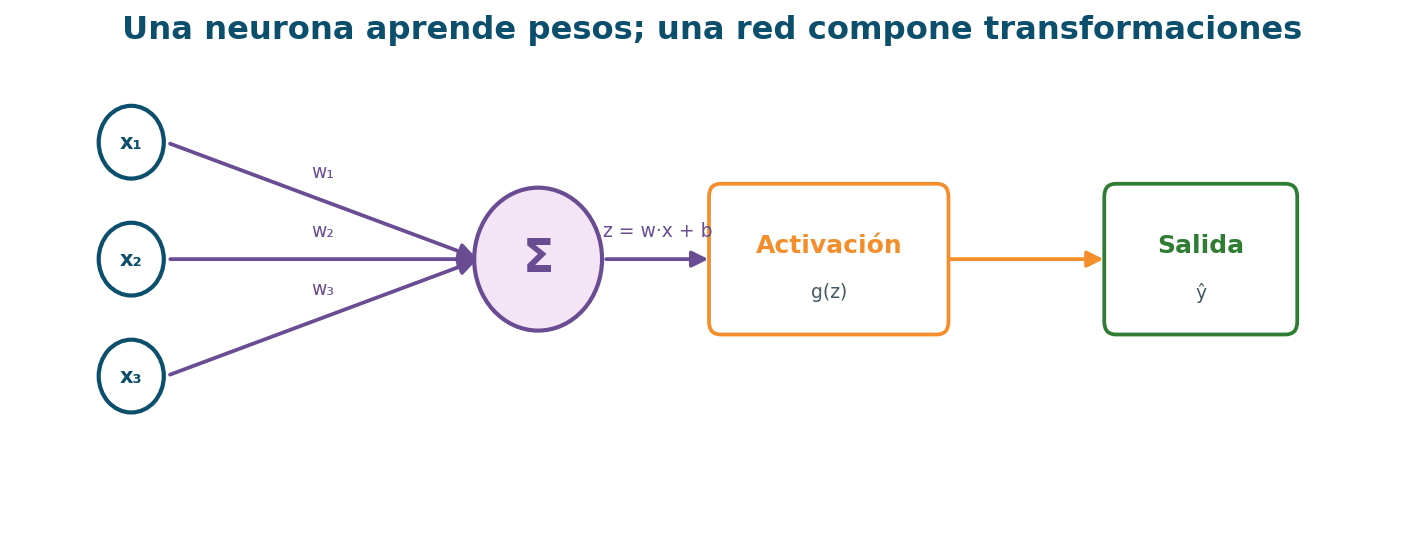

Cada entrada se multiplica por un peso; la suma incorpora un sesgo y pasa por una función de activación. Durante el entrenamiento, la retropropagación calcula cómo debe cambiar cada peso para reducir la pérdida.

### Conceptos esenciales

Para una neurona:

$$z = \mathbf{w}^{\top}\mathbf{x} + b, \qquad a = g(z)$$

En una red multicapa, la salida de una capa se convierte en la entrada de la siguiente. La última capa tiene una
neurona por clase y produce puntuaciones que se transforman en probabilidades. El entrenamiento minimiza una
función de pérdida mediante L-BFGS en la implementación de MLlib.

**Interpretación:** agregar capas incrementa la capacidad, pero también el costo y el riesgo de sobreajuste.

### Arquitectura utilizada

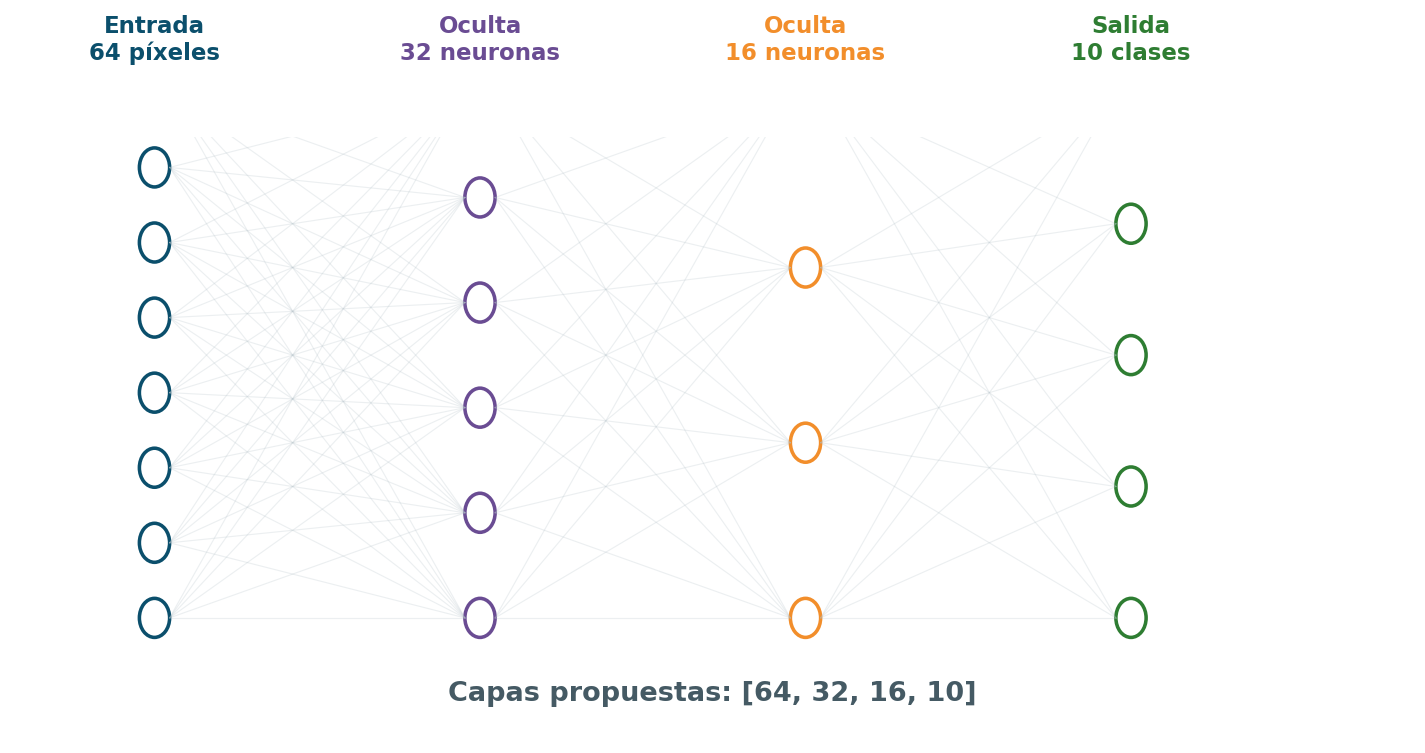

Las 64 entradas corresponden a una imagen de 8 × 8 píxeles. Las capas ocultas comprimen y recombinan patrones. La capa final contiene diez salidas, una para cada dígito de 0 a 9. Los tamaños son una decisión experimental, no una regla universal.

## 1. Preparación del entorno

El notebook funciona en Google Colab, Jupyter o local con Java 11/17, PySpark 3.5.x, scikit-learn y Matplotlib.
Las instalaciones se realizan únicamente cuando una dependencia no está disponible.

In [1]:
import importlib.util
import subprocess
import sys

requeridas = {
    "pyspark": "pyspark==3.5.1",
    "sklearn": "scikit-learn>=1.4,<1.6",
    "matplotlib": "matplotlib>=3.7",
}
faltantes = [paquete for modulo, paquete in requeridas.items() if importlib.util.find_spec(modulo) is None]
if faltantes:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltantes])

import pyspark
import sklearn
print("PySpark:", pyspark.__version__)
print("scikit-learn:", sklearn.__version__)

PySpark: 4.0.4
scikit-learn: 1.6.1


In [2]:
from pathlib import Path
import json
import math
import os
import shutil

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml.functions import vector_to_array
from pyspark.ml.linalg import VectorUDT, Vectors
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from sklearn.datasets import load_digits

BASE = Path("/tmp/mineria_pyspark_redes")
BASE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("MineriaDatos2027-RedesNeuronales")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.ui.showConsoleProgress", "false")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)
print("Master:", spark.sparkContext.master)

Spark: 4.0.4
Master: local[*]


## 2. Datos reales: dígitos escritos a mano

`load_digits` contiene 1 797 imágenes reales de dígitos escritos a mano. Cada imagen tiene 8 × 8 píxeles en escala
de grises y se representa mediante 64 valores entre 0 y 16. Es un problema multiclase pequeño, visual y adecuado
para comparar arquitecturas sin una descarga externa.

In [3]:
digits = load_digits()
X = digits.data.astype(float)
y = digits.target.astype(int)

print("Imágenes:", X.shape[0])
print("Variables por imagen:", X.shape[1])
print("Clases:", sorted(np.unique(y).tolist()))
print("Rango de intensidad:", (X.min(), X.max()))

Imágenes: 1797
Variables por imagen: 64
Clases: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Rango de intensidad: (np.float64(0.0), np.float64(16.0))


In [4]:
fig, axes = plt.subplots(2, 6, figsize=(10, 3.8))
for ax, image, etiqueta in zip(axes.ravel(), digits.images[:12], y[:12]):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"Etiqueta: {etiqueta}")
    ax.axis("off")
fig.suptitle("Muestra del conjunto Digits", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### De matriz a vector

Una capa densa recibe un vector, no una matriz bidimensional. Al aplanar 8 × 8 se conservan las intensidades, pero
se pierde la estructura espacial explícita. Una CNN aprovecha vecindades y patrones locales; el MLP debe aprender
esas relaciones solo a partir de conexiones densas.

In [5]:
esquema = T.StructType([
    T.StructField("id", T.IntegerType(), False),
    T.StructField("features_raw", VectorUDT(), False),
    T.StructField("label", T.DoubleType(), False),
])
filas = [(int(i), Vectors.dense(X[i].tolist()), float(y[i])) for i in range(len(y))]
'''1. Why are these being transformed to float? In order to gain precision when
multiplications are actually done?'''
datos = spark.createDataFrame(filas, schema=esquema).repartition(8)

datos.printSchema()
print("Filas:", datos.count(), "| Particiones:", datos.rdd.getNumPartitions())
datos.select("id", "label", "features_raw").show(3, truncate=70)

root
 |-- id: integer (nullable = false)
 |-- features_raw: vector (nullable = false)
 |-- label: double (nullable = false)

Filas: 1797 | Particiones: 8
+---+-----+----------------------------------------------------------------------+
| id|label|                                                          features_raw|
+---+-----+----------------------------------------------------------------------+
|658|  2.0|[0.0,0.0,6.0,15.0,15.0,1.0,0.0,0.0,0.0,4.0,16.0,13.0,16.0,4.0,0.0,0...|
|505|  9.0|[0.0,0.0,3.0,10.0,14.0,3.0,0.0,0.0,0.0,4.0,16.0,13.0,15.0,11.0,0.0,...|
|587|  5.0|[0.0,1.0,9.0,12.0,13.0,11.0,0.0,0.0,0.0,3.0,15.0,4.0,3.0,3.0,0.0,0....|
+---+-----+----------------------------------------------------------------------+
only showing top 3 rows


0. These numbers are how much intensity does the scales of gray have.

In [6]:
distribucion = datos.groupBy("label").count().orderBy("label")
distribucion.show()

dist_pd = distribucion.toPandas()
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(dist_pd["label"].astype(int).astype(str), dist_pd["count"], color="#0B4F6C")
ax.set(title="Distribución de clases", xlabel="Dígito", ylabel="Imágenes")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|  178|
|  1.0|  182|
|  2.0|  177|
|  3.0|  183|
|  4.0|  181|
|  5.0|  182|
|  6.0|  181|
|  7.0|  179|
|  8.0|  174|
|  9.0|  180|
+-----+-----+



### Actividad 1 · Leer antes de modelar

1. ¿El conjunto está fuertemente desbalanceado?
2. ¿Qué información espacial se pierde al aplanar la imagen?
3. ¿Qué transformación sería indispensable si los píxeles tuvieran escalas diferentes?
4. ¿Por qué convertir las 1 797 filas a pandas sería posible aquí, pero una mala práctica general para datos grandes?

## 3. Separación y escalamiento

La prueba se separa antes de ajustar el escalador. `MinMaxScaler` lleva cada variable al intervalo configurado y
forma parte del pipeline, por lo que el mismo ajuste se reutiliza durante la inferencia.

In [8]:
entrenamiento, prueba = datos.randomSplit([0.8, 0.2], seed=42)
entrenamiento = entrenamiento.cache()
prueba = prueba.cache()
'''2. How does Spark know what information it must send to the cache? If
`entrenamiento` and `prueba` are both in cache how does it know which is which?
Also, in which level of memory are these saved? I assume it puts both on the largest,
fastest memory than it can. If both can be into L1 then they put it there, if not
then we go to L2, then L3. '''

n_train = entrenamiento.count()
n_test = prueba.count()
print("Entrenamiento:", n_train, "| Prueba:", n_test)
print("Clases en entrenamiento:", entrenamiento.select("label").distinct().count())
print("Clases en prueba:", prueba.select("label").distinct().count())

Entrenamiento: 1444 | Prueba: 353
Clases en entrenamiento: 10
Clases en prueba: 10


In [9]:
scaler = MinMaxScaler(
    inputCol="features_raw",
    outputCol="features",
    min=0.0,
    max=1.0,
)

## 4. Diseño y entrenamiento de la red

La lista `layers` incluye entrada y salida. Para Digits:

- 64 neuronas de entrada: una por píxel;
- 32 y 16 neuronas ocultas;
- 10 neuronas de salida: una por clase.

`blockSize` define cuántas observaciones se procesan por bloque. `maxIter` limita las iteraciones del optimizador.
La semilla hace reproducible la inicialización, aunque un entorno distribuido puede introducir pequeñas variaciones.

In [11]:
arquitectura = [64, 32, 16, 10]
'''7. The reason why we use multipliers of 32 is that it is normally the number
of threads in a warp in most architectures. Wouldn't it be better here to have 32
and again 32? I suppose the partition in half is to simulate some kind of
"dropout" in order to force the model to compress and learn. If we had the two
as equal I imagine there might be a place in which the second hidden layer of
neurons are practically a copy of the first ones (which should be unlikely, as
the dense interconnections of neurons should provide some mixture).'''
mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    layers=arquitectura,
    blockSize=64,
    maxIter=120,
    tol=1e-6,
    seed=42,
)

pipeline = Pipeline(stages=[scaler, mlp])
modelo = pipeline.fit(entrenamiento)
predicciones = modelo.transform(prueba).cache()
'''2. This new `.cache()` seems to disprove my idea about the cache: How can know
pyspark how many caches are being needed? If Python was a compiled language that
would work, but as it is interpreted it really has no idea of how many things
it is going to store in cache until it actually gets the instruction. '''

predicciones.select("id", "label", "prediction", "probability").show(5, truncate=70)

+---+-----+----------+----------------------------------------------------------------------+
| id|label|prediction|                                                           probability|
+---+-----+----------+----------------------------------------------------------------------+
| 43|  7.0|       7.0|[7.666071228880886E-28,9.948702433294614E-22,1.3457167620724008E-24...|
| 73|  9.0|       9.0|[7.76128813733215E-15,3.8922818131786474E-22,9.520185217735676E-18,...|
|106|  6.0|       6.0|[2.5193166192473168E-26,4.428290139875778E-18,1.0516747266622752E-2...|
|151|  1.0|       1.0|[1.6667636642116503E-19,0.9999999985411407,3.255879573060097E-11,3....|
|184|  2.0|       2.0|[2.10595407972487E-35,7.560298260351624E-11,0.9999999998383289,3.45...|
+---+-----+----------+----------------------------------------------------------------------+
only showing top 5 rows


In [12]:
modelo_mlp = modelo.stages[-1]
resumen = modelo_mlp.summary
historia = list(resumen.objectiveHistory) if hasattr(resumen, "objectiveHistory") else []

if historia:
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(range(1, len(historia) + 1), historia, color="#F28E2B", linewidth=2)
    ax.set(title="Evolución de la función objetivo", xlabel="Iteración", ylabel="Objetivo")
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()
    print("Iteraciones registradas:", len(historia))
else:
    print("La versión instalada no expone objectiveHistory para este modelo.")

La versión instalada no expone objectiveHistory para este modelo.


### Cómo leer la curva

Una disminución sostenida indica que el optimizador encuentra parámetros con menor pérdida. Una meseta puede
significar convergencia, una tolerancia alcanzada o una arquitectura difícil de optimizar. La curva de entrenamiento
por sí sola no demuestra generalización: siempre debe contrastarse con datos no utilizados durante el ajuste.

## 5. Evaluación multiclase

Accuracy resume aciertos globales. Las métricas ponderadas consideran el desempeño por clase y su frecuencia.
La matriz de confusión muestra qué pares de dígitos se confunden y orienta el análisis cualitativo.

In [13]:
metricas = {}
for nombre, metrica in [
    ("Accuracy", "accuracy"),
    ("Precisión ponderada", "weightedPrecision"),
    ("Recall ponderado", "weightedRecall"),
    ("F1 ponderado", "f1"),
]:
    evaluador = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName=metrica
    )
    metricas[nombre] = evaluador.evaluate(predicciones)

{nombre: round(valor, 4) for nombre, valor in metricas.items()}

{'Accuracy': 0.9688,
 'Precisión ponderada': 0.9692,
 'Recall ponderado': 0.9688,
 'F1 ponderado': 0.9689}

In [14]:
matriz = (
    predicciones
    .groupBy("label")
    .pivot("prediction", [float(i) for i in range(10)])
    .count()
    .fillna(0)
    .orderBy("label")
)
matriz.show(truncate=False)

matriz_pd = matriz.toPandas().set_index("label")
fig, ax = plt.subplots(figsize=(7, 6))
imagen = ax.imshow(matriz_pd.values, cmap="Blues")
ax.set(
    title="Matriz de confusión",
    xlabel="Predicción",
    ylabel="Etiqueta real",
    xticks=range(10),
    yticks=range(10),
)
for i in range(10):
    for j in range(10):
        valor = int(matriz_pd.iloc[i, j])
        if valor:
            ax.text(j, i, valor, ha="center", va="center", fontsize=8,
                    color="white" if valor > matriz_pd.values.max() * 0.55 else "black")
fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
plt.show()

+-----+---+---+---+---+---+---+---+---+---+---+
|label|0.0|1.0|2.0|3.0|4.0|5.0|6.0|7.0|8.0|9.0|
+-----+---+---+---+---+---+---+---+---+---+---+
|0.0  |39 |0  |0  |0  |0  |0  |0  |0  |0  |0  |
|1.0  |0  |35 |0  |0  |0  |0  |0  |0  |0  |1  |
|2.0  |0  |0  |38 |0  |0  |0  |1  |0  |0  |0  |
|3.0  |0  |0  |0  |40 |0  |0  |0  |0  |0  |1  |
|4.0  |0  |0  |0  |0  |27 |0  |0  |0  |0  |0  |
|5.0  |0  |0  |0  |0  |0  |34 |1  |0  |0  |0  |
|6.0  |1  |0  |0  |0  |0  |0  |35 |0  |0  |0  |
|7.0  |0  |0  |0  |0  |1  |1  |0  |36 |0  |1  |
|8.0  |0  |0  |0  |0  |0  |0  |0  |0  |29 |0  |
|9.0  |0  |0  |0  |0  |0  |1  |0  |2  |0  |29 |
+-----+---+---+---+---+---+---+---+---+---+---+



4. Recall can be seen as the "true positives", in which 0 did not commit any mistake on its rows (how many times a true zero got labeled as other numbers), however the accuracy can be seen as the "false positives", in which a 6 got confused into a 0 one time. That is why the recall is 1 but the accuracy is not.

In [15]:
clases = spark.createDataFrame([(float(i),) for i in range(10)], "clase double")
reales = predicciones.groupBy(F.col("label").alias("clase")).agg(F.count("*").alias("reales"))
predichas = predicciones.groupBy(F.col("prediction").alias("clase")).agg(F.count("*").alias("predichas"))
correctas = (
    predicciones.filter(F.col("label") == F.col("prediction"))
    .groupBy(F.col("label").alias("clase"))
    .agg(F.count("*").alias("correctas"))
)

por_clase = (
    clases.join(reales, "clase", "left")
    .join(predichas, "clase", "left")
    .join(correctas, "clase", "left")
    .fillna(0)
    .withColumn("precision", F.col("correctas") / F.greatest(F.col("predichas"), F.lit(1)))
    .withColumn("recall", F.col("correctas") / F.greatest(F.col("reales"), F.lit(1)))
    .withColumn(
        "f1",
        2 * F.col("precision") * F.col("recall")
        / F.greatest(F.col("precision") + F.col("recall"), F.lit(1e-12))
    )
    .orderBy("clase")
)
por_clase.select("clase", "reales", "precision", "recall", "f1").show(10, truncate=False)

+-----+------+------------------+------------------+------------------+
|clase|reales|precision         |recall            |f1                |
+-----+------+------------------+------------------+------------------+
|0.0  |39    |0.975             |1.0               |0.9873417721518987|
|1.0  |36    |1.0               |0.9722222222222222|0.9859154929577464|
|2.0  |39    |1.0               |0.9743589743589743|0.9870129870129869|
|3.0  |41    |1.0               |0.975609756097561 |0.9876543209876543|
|4.0  |27    |0.9642857142857143|1.0               |0.9818181818181818|
|5.0  |35    |0.9444444444444444|0.9714285714285714|0.9577464788732395|
|6.0  |36    |0.9459459459459459|0.9722222222222222|0.9589041095890412|
|7.0  |39    |0.9473684210526315|0.9230769230769231|0.935064935064935 |
|8.0  |29    |1.0               |1.0               |1.0               |
|9.0  |32    |0.90625           |0.90625           |0.90625           |
+-----+------+------------------+------------------+------------

### Actividad 2 · Diagnóstico por clase

Identifique:

1. las dos clases con menor recall;
2. el par de dígitos con más confusiones;
3. una explicación visual plausible;
4. una modificación de arquitectura o datos que podría reducir ese error.

## 6. Confianza, incertidumbre y errores

La probabilidad máxima es una medida de confianza interna, no una garantía de corrección. La entropía aumenta
cuando la distribución de probabilidad está más repartida entre clases. Conviene revisar tanto errores confiados
como casos inciertos.

In [17]:
evaluadas = (
    predicciones
    .withColumn("probabilidades", vector_to_array("probability"))
    .withColumn("confianza", F.array_max("probabilidades"))
    .withColumn(
        "entropia",
        F.aggregate(
            "probabilidades",
            F.lit(0.0),
            lambda acc, p: acc - p * F.log(F.greatest(p, F.lit(1e-12)))
        )
    )
    .withColumn("correcta", (F.col("label") == F.col("prediction")).cast("int"))
)
evaluadas.select("label", "prediction", "confianza", "entropia", "correcta").summary().show()

'''6. What I don't understand is the relationship between a normal distribution and
entropy. The highest entropy, under my understanding, is that there is a rectangle
in which all the classes have the same probability, but in actual real systems we
don't have rectangles, but "Gaussian Bells". Indeed for what I understand white noise
as well as brownian motion follow practically the same pattern. Under this view
it seems that while the entropy in the universe tends to increment, there seems
to be a limit in which this entropy can continue to increase.'''

+-------+------------------+------------------+-------------------+--------------------+-------------------+
|summary|             label|        prediction|          confianza|            entropia|           correcta|
+-------+------------------+------------------+-------------------+--------------------+-------------------+
|  count|               353|               353|                353|                 353|                353|
|   mean| 4.331444759206799| 4.337110481586402|  0.992744457958381|0.013952642840581833| 0.9688385269121813|
| stddev|2.8704118345496585|2.8687599537811166|0.05406301102905041| 0.10053451935562506|0.17400058610822455|
|    min|               0.0|               0.0|0.48054279262303673|2.091053274981227...|                  0|
|    25%|               2.0|               2.0| 0.9999999998210698|3.914917492078667...|                  1|
|    50%|               4.0|               4.0| 0.9999999999889406|2.900681539842301...|                  1|
|    75%|          

'6. What I don\'t understand is the relationship between a normal distribution and\nentropy. The highest entropy, under my understanding, is that there is a rectangle\nin which all the classes have the same probability, but in actual real systems we\ndon\'t have rectangles, but "Gaussian Bells". Indeed for what I understand white noise\nas well as brownian motion follow practically the same pattern. Under this view \nit seems that while the entropy in the universe tends to increment, there seems\nto be a limit in which this entropy can continue to increase.'

In [18]:
confianza_pd = evaluadas.select("confianza", "correcta").toPandas()
fig, ax = plt.subplots(figsize=(8, 3.8))
for correcta, etiqueta, color in [(1, "Correctas", "#2E7D32"), (0, "Errores", "#D55E00")]:
    valores = confianza_pd.loc[confianza_pd.correcta == correcta, "confianza"]
    ax.hist(valores, bins=15, alpha=0.58, label=etiqueta, color=color)
ax.set(title="Confianza del modelo", xlabel="Probabilidad máxima", ylabel="Casos")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [19]:
errores = (
    evaluadas
    .filter(F.col("correcta") == 0)
    .orderBy(F.desc("confianza"))
    .select("id", "label", "prediction", "confianza", vector_to_array("features_raw").alias("pixeles"))
    .limit(12)
    .collect()
)

if errores:
    fig, axes = plt.subplots(2, 6, figsize=(10, 4))
    for ax, fila in zip(axes.ravel(), errores):
        ax.imshow(np.array(fila.pixeles).reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
        ax.set_title(f"Real {int(fila.label)} → {int(fila.prediction)}\nP={fila.confianza:.2f}")
        ax.axis("off")
    for ax in axes.ravel()[len(errores):]:
        ax.axis("off")
    fig.suptitle("Errores con mayor confianza", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Interpretación responsable

Un error con confianza alta es más preocupante que un error incierto porque el sistema no expresa duda. Antes de
usar la salida para una decisión real, deben definirse umbrales, revisión humana y comportamiento ante entradas
fuera de distribución.

## 7. Comparación opcional de arquitecturas

La comparación mantiene el mismo entrenamiento, prueba, escalador y semilla. Solo cambia la arquitectura. Esto no
constituye una búsqueda exhaustiva, pero permite observar la relación entre capacidad, tiempo y generalización.

In [20]:
EJECUTAR_COMPARACION = False
resultados_arquitecturas = []

if EJECUTAR_COMPARACION:
    alternativas = [
        [64, 16, 10],
        [64, 32, 16, 10],
        [64, 64, 32, 10],
    ]
    evaluador_accuracy = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    )
    for capas in alternativas:
        candidato = MultilayerPerceptronClassifier(
            featuresCol="features", labelCol="label", layers=capas,
            blockSize=64, maxIter=100, seed=42
        )
        pipeline_candidato = Pipeline(stages=[scaler, candidato])
        modelo_candidato = pipeline_candidato.fit(entrenamiento)
        accuracy = evaluador_accuracy.evaluate(modelo_candidato.transform(prueba))
        parametros = sum((capas[i] + 1) * capas[i + 1] for i in range(len(capas) - 1))
        resultados_arquitecturas.append((str(capas), int(parametros), float(accuracy)))

    spark.createDataFrame(
        resultados_arquitecturas, "arquitectura string, parametros int, accuracy double"
    ).show(truncate=False)
else:
    print("Comparación omitida. Cambie EJECUTAR_COMPARACION a True para entrenar tres arquitecturas.")

Comparación omitida. Cambie EJECUTAR_COMPARACION a True para entrenar tres arquitecturas.


### Actividad 3 · Capacidad y sobreajuste

Active la comparación y responda:

- ¿más parámetros producen siempre mayor accuracy?
- ¿qué arquitectura ofrece el mejor equilibrio entre desempeño y complejidad?
- ¿qué información adicional necesitaría para afirmar que existe sobreajuste?

## 8. Persistencia e inferencia distribuida

Guardar el `PipelineModel` conserva escalador y red en una sola unidad. En producción debe acompañarse de versión
de datos, código, parámetros, métricas y contrato de entrada.

In [ ]:
ruta_modelo = BASE / "pipeline_mlp_digits"
if ruta_modelo.exists():
    shutil.rmtree(ruta_modelo)

modelo.write().overwrite().save(str(ruta_modelo))
modelo_recargado = PipelineModel.load(str(ruta_modelo))

muestra_inferencia = prueba.orderBy("id").limit(20)
pred_original = [r.prediction for r in modelo.transform(muestra_inferencia).select("prediction").collect()]
pred_recargada = [r.prediction for r in modelo_recargado.transform(muestra_inferencia).select("prediction").collect()]
assert pred_original == pred_recargada
print("Pipeline recargado y verificado con 20 observaciones.")

Pipeline recargado y verificado con 20 observaciones.


In [ ]:
registro = {
    "curso": "Minería de datos 2027-1",
    "spark_version": spark.version,
    "dataset": "sklearn.datasets.load_digits",
    "filas_entrenamiento": n_train,
    "filas_prueba": n_test,
    "arquitectura": arquitectura,
    "metricas": {k: float(v) for k, v in metricas.items()},
}
ruta_registro = BASE / "registro_mlp.json"
ruta_registro.write_text(json.dumps(registro, indent=2, ensure_ascii=False), encoding="utf-8")
print(ruta_registro.read_text(encoding="utf-8"))

{
  "curso": "Minería de datos 2027-1",
  "spark_version": "4.0.4",
  "dataset": "sklearn.datasets.load_digits",
  "filas_entrenamiento": 1444,
  "filas_prueba": 353,
  "arquitectura": [
    64,
    32,
    16,
    10
  ],
  "metricas": {
    "Accuracy": 0.9688385269121813,
    "Precisión ponderada": 0.9691719329075822,
    "Recall ponderado": 0.9688385269121813,
    "F1 ponderado": 0.9688524606141514
  }
}


## 9. ¿Cuándo usar otra biblioteca?

| Necesidad | MLlib MLP | Alternativa habitual |
|---|---:|---|
| Clasificación tabular con red densa | Adecuado | También scikit-learn o PyTorch |
| CNN para imágenes | No | TensorFlow o PyTorch |
| LSTM/GRU para secuencias | No | TensorFlow o PyTorch |
| GPU y entrenamiento profundo | Muy limitado | PyTorch/TensorFlow distribuidos |
| ETL de gran volumen | Muy adecuado | PySpark |
| Inferencia integrada con DataFrames | Adecuado | UDF vectorizada o servicio externo |

Un patrón frecuente es usar Spark para lectura, limpieza, particionamiento y construcción de variables; después se
exportan conjuntos controlados para entrenar con una biblioteca profunda. La elección debe considerar volumen,
arquitectura, hardware, latencia y operación del modelo.

## 10. Retos de ampliación

### Reto A · Ruido
Añada ruido a los píxeles de prueba y mida cómo cambia accuracy. Grafique ejemplos antes y después.

### Reto B · Arquitectura
Compare una capa oculta contra dos capas. Mantenga fijo el resto del experimento y reporte número de parámetros.

### Reto C · Clases difíciles
Seleccione las dos clases con menor F1 y construya una explicación basada en imágenes confundidas.

### Reto D · Rechazo por incertidumbre
Defina un umbral de confianza. Reporte cobertura —porcentaje de casos aceptados— y accuracy solo en casos aceptados.

### Reto E · Pipeline productivo
Proponga contrato de entrada, monitoreo de datos, alerta de deriva y criterio de reentrenamiento.

In [ ]:
# Plantilla del reto D: cobertura y accuracy al rechazar casos inciertos.
umbrales = [0.50, 0.60, 0.70, 0.80, 0.90]
resultados_rechazo = []
total = evaluadas.count()

for umbral in umbrales:
    aceptadas = evaluadas.filter(F.col("confianza") >= umbral)
    n = aceptadas.count()
    aciertos = aceptadas.agg(F.avg("correcta").alias("accuracy")).first()["accuracy"] if n else None
    resultados_rechazo.append((float(umbral), float(n / total), None if aciertos is None else float(aciertos)))

spark.createDataFrame(
    resultados_rechazo, "umbral double, cobertura double, accuracy_aceptadas double"
).show(truncate=False)

+------+------------------+------------------+
|umbral|cobertura         |accuracy_aceptadas|
+------+------------------+------------------+
|0.5   |0.9943342776203966|0.9715099715099715|
|0.6   |0.9915014164305949|0.9742857142857143|
|0.7   |0.9830028328611898|0.9798270893371758|
|0.8   |0.9830028328611898|0.9798270893371758|
|0.9   |0.9830028328611898|0.9798270893371758|
+------+------------------+------------------+



## Lista de verificación

- [ ] La dimensión de entrada coincide con la primera capa.
- [ ] La cantidad de clases coincide con la última capa.
- [ ] El escalador se ajusta solo con entrenamiento.
- [ ] Todas las clases aparecen en entrenamiento y prueba.
- [ ] Se reportan métricas globales y por clase.
- [ ] Se revisan confusiones y errores con confianza alta.
- [ ] La arquitectura se compara bajo condiciones equivalentes.
- [ ] El pipeline y el registro experimental se versionan juntos.
- [ ] Se reconocen las limitaciones de MLlib para aprendizaje profundo.

## Recursos de consulta

- [MultilayerPerceptronClassifier](https://spark.apache.org/docs/3.5.1/api/python/reference/api/pyspark.ml.classification.MultilayerPerceptronClassifier.html)
- [Pipelines de MLlib](https://spark.apache.org/docs/3.5.1/ml-pipeline.html)
- [Conjunto Digits](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)
- [Evaluación multiclase en MLlib](https://spark.apache.org/docs/3.5.1/api/python/reference/api/pyspark.ml.evaluation.MulticlassClassificationEvaluator.html)

In [ ]:
DETENER_SPARK = False
if DETENER_SPARK:
    entrenamiento.unpersist()
    prueba.unpersist()
    predicciones.unpersist()
    spark.stop()
    print("Sesión detenida.")
else:
    print("La sesión permanece activa.")

La sesión permanece activa.
